In [1]:
import h5py
from spectre.Visualization.ReadH5 import to_dataframe
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import glob
from spectre.Pipelines.ScalarSelfForce.Assemble import (
    assemble_scalar_self_force, sum_Fr4
)
from spectre.support.Schedule import schedule
from scipy.optimize import minimize
from spectre.PointwiseFunctions.AnalyticData.ScalarSelfForce import (
    CircularOrbit,
)
from spectre.Visualization.PlotEllipticConvergence import split_iteration_sequence
pd.set_option('display.float_format', '{:.6e}'.format)
plt.style.use("/Users/nilsvu/Projects/Papers/2024/dg-self-force/scripts/paper.mplstyle")
# plt.style.use("/Users/nilsvu/Projects/spectre/src/Visualization/Python/plots.mplstyle")

In [ ]:
import h5py
import matplotlib.pyplot as plt
from spectre.Visualization.ReadH5 import to_dataframe
# Load data
with h5py.File("/Users/nilsvu/Projects/spectre/build-Default-Release/test_ssf/ScalarSelfForceReductions.h5", "r") as f:
    df = to_dataframe(f["SelfForce.dat"]).set_index("IterationId")
# Average over neighboring elements at the puncture
self_force = df["Re(SelfForce_r)"].groupby("IterationId").mean()
# Plot difference to reference value
plt.semilogy(np.abs(self_force.iloc[1:] - -1.32916e-06), marker=".")

In [2]:
def r_isco(a):
    return minimize(
        lambda r: np.abs(
            1.0
            - 6.0 / r
            + 8.0 * a * np.sqrt(1.0 / r**3)
            - 3.0 * a**2 / r**2
        ),
        x0=6.0,
        bounds=[[2.0, 12.0]],
    ).x[0]

In [3]:
def r_plus(a):
    return 1 + np.sqrt(1 - a**2)

In [21]:
a = 0.5
r_0 = r_isco(a=a)
# r_0 = 10
r_p = r_plus(a=a)
r_0, r_p, (r_0 - r_p) * 0.5

(np.float64(4.2330025279799335),
 np.float64(1.8660254037844386),
 np.float64(1.1834885620977476))

In [592]:
%%file run.py
from rich.progress import track
import numpy as np
from spectre.support.Schedule import schedule
from scipy.optimize import minimize

def r_isco(a):
    return minimize(
        lambda r: np.abs(
            1.0
            - 6.0 / r
            + 8.0 * a * np.sqrt(1.0 / r**3)
            - 3.0 * a**2 / r**2
        ),
        x0=6.0,
        bounds=[[2.0, 12.0]],
    ).x[0]
def r_plus(a):
    return 1 + np.sqrt(1 - a**2)
spins = [-0.998, -0.9, -0.7, -0.5, 0.0, 0.5, 0.7, 0.9, 0.998]
for rad in track([None, 10]):
    for a in track(spins):
        r_0 = rad or r_isco(a)
        r_p = r_plus(a)
        dr = (r_0 - r_p) * 0.6
        for m in track(range(0, 21)):
            schedule(
                "/Users/nilsvu/Projects/spectre/support/Pipelines/SelfForce/Scalar/ScalarSelfForce.yaml",
                run_dir="test_ssf73/r_{{r_desc}}/a{{spin}}/m{{m_mode}}",
                r_desc=str(rad or "isco"),
                spin=a,
                m_mode=m,
                orbital_radius=r_0,
                inner_radius=r_p,
                outer_radius=1e4,
                worldtube_radius=dr,
                worldtube_dcostheta=0.5,
                P=4,
                L=0,
                scheduler=None,
                skip_existing=True,
                validate=False,
            )

Overwriting run.py


Tests for a=0.5, r0=10:

In [424]:
reference_sf = [[0.0,1.2652680881156312e-4,0.0],[2.4785455300555827e-5,-1.365170710329026e-4,-7.961776435907745e-4],[7.278128194979127e-6,-1.3291572725501146e-6,-2.3379368608573035e-4],[1.5902782332125908e-6,3.810535142852179e-6,-5.108415242000836e-5],[3.1470207660903283e-7,1.8752915639242087e-6,-1.0109104502997938e-5],[5.927827175925205e-8,7.894165575527185e-7,-1.9041826810563553e-6],[1.0842628182184181e-8,3.5022493341675776e-7,-3.4829532287142357e-7],[1.9451658024130903e-9,1.728350021488344e-7,-6.24841265241506e-8],[3.442183592031139e-10,9.477515040410666e-8,-1.1057249454879772e-8],[6.030046023090095e-11,5.659994853067909e-8,-1.937018212975947e-9],[1.048485424739129e-11,3.606853703505297e-8,-3.368026306901663e-10],[1.8154522536539399e-12,2.4152151102844248e-8,-5.831736717514891e-11],[3.163401444401203e-13,1.681516511865068e-8,-1.0161723789994383e-11],[5.856091806554566e-14,1.2081052288814544e-8,-1.8811392886090083e-12],[1.005629719844026e-14,8.912253993840976e-9,-3.230361883456454e-13],[2.5547975585393953e-15,6.720955189144775e-9,-8.206719123550592e-14],[1.3232706968479388e-15,5.165377999173894e-9,-4.250712897841582e-14],[1.1303280217524028e-15,4.036673828078404e-9,-3.6309274529377496e-14],[8.369124285619239e-14,3.1378689354465253e-9,-2.6883950977867265e-12],[1.2627894025883892e-15,2.5700095206125453e-9,-4.0564301874314637e-14],[6.9551077293623195e-15,2.0826933752730703e-9,-2.234173718309494e-13]]
reference_sf = np.array(reference_sf)

In [5]:
import pandas as pd

ssf_ref = pd.DataFrame(
    [
        # r0 = 10M
        [10, -0.9,  4.939995e-5],
        [10, -0.7,  4.100712e-5],
        [10, -0.5,  3.28942e-5],
        [10,  0.0,  1.378448e-5],
        [10,  0.5, -4.03517e-6],
        [10,  0.7, -1.091819e-5],
        [10,  0.9, -1.768232e-5],

        # r0 = r_ISCO
        [None, -0.9,  9.607001e-5],
        [None, -0.7,  1.107625e-4],
        [None, -0.5,  1.275170e-4],
        [None,  0.0,  1.677283e-4],
        [None,  0.5, -6.922147e-5],
        [None,  0.7, -1.088457e-3],
        [None,  0.9, -1.133673e-2],
    ],
    columns=["r0", "a", "SelfForce_r"],
).set_index(["r0", "a"])

In [6]:
np.sum(reference_sf[:, 1]) + sum_Fr4(r0=10, a=0.5, m_max=len(reference_sf) - 1)

NameError: name 'reference_sf' is not defined

In [7]:
def get_data(file_path):
    with h5py.File(file_path, "r") as h5file:
        df = to_dataframe(h5file["SelfForce.dat"]).groupby("IterationId").mean().iloc[1:]
        num_points = to_dataframe(h5file["Norms.dat"]).set_index("IterationId(Amr)")["NumberOfPoints"].iloc[1:]
        walltime = [df_amr["Walltime"].iloc[-1] for df_amr in split_iteration_sequence(to_dataframe(h5file["GmresResiduals.dat"]).set_index("Iteration"))]
    return pd.DataFrame(
        {
            "SelfForce_r": df["Re(SelfForce_r)"],
            "NumPoints": num_points,
            "Walltime": walltime if len(walltime) == len(df) else [np.nan] * len(df),
        },
    )

In [8]:
def ssf_stats(df, r0, a, isco):
    idx = (None if isco else r0, a)
    renorm_sum = sum_Fr4(r0=r0, a=a, m_max=len(df) - 1)
    ssf_sum_m = df["SelfForce_r"].sum() + renorm_sum
    ssf_sum_m_skip_1 = df["SelfForce_r"].iloc[:-1].sum() + sum_Fr4(r0=r0, a=a, m_max=len(df) - 2)
    ssf_sum_skip_hires = df["SelfForce_r_lo"].sum() + renorm_sum
    return (
        ssf_sum_m,
        np.abs(ssf_sum_m - ssf_sum_m_skip_1) / np.abs(ssf_sum_m),
        np.abs(ssf_sum_m - ssf_sum_skip_hires) / np.abs(ssf_sum_m),
        np.abs(ssf_sum_m - ssf_ref.loc[idx, "SelfForce_r"]) / np.abs(ssf_sum_m) if idx in ssf_ref.index else np.nan,
    )

<>:107: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:112: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:107: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:112: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/var/folders/xp/5t2ny359187c4ljckf8sz3m80000gn/T/ipykernel_95422/2566131927.py:107: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.ylabel("Absolute error $|F_r^m - F_{r,\mathrm{ref}}^m|$")
/var/folders/xp/5t2ny359187c4ljckf8sz3m80000gn/T/ipykernel_95422/2566131927.py:112: S

([<matplotlib.axis.YTick at 0x136dd11d0>,
 [Text(0, 1, '1 s'), Text(0, 10, '10 s')])

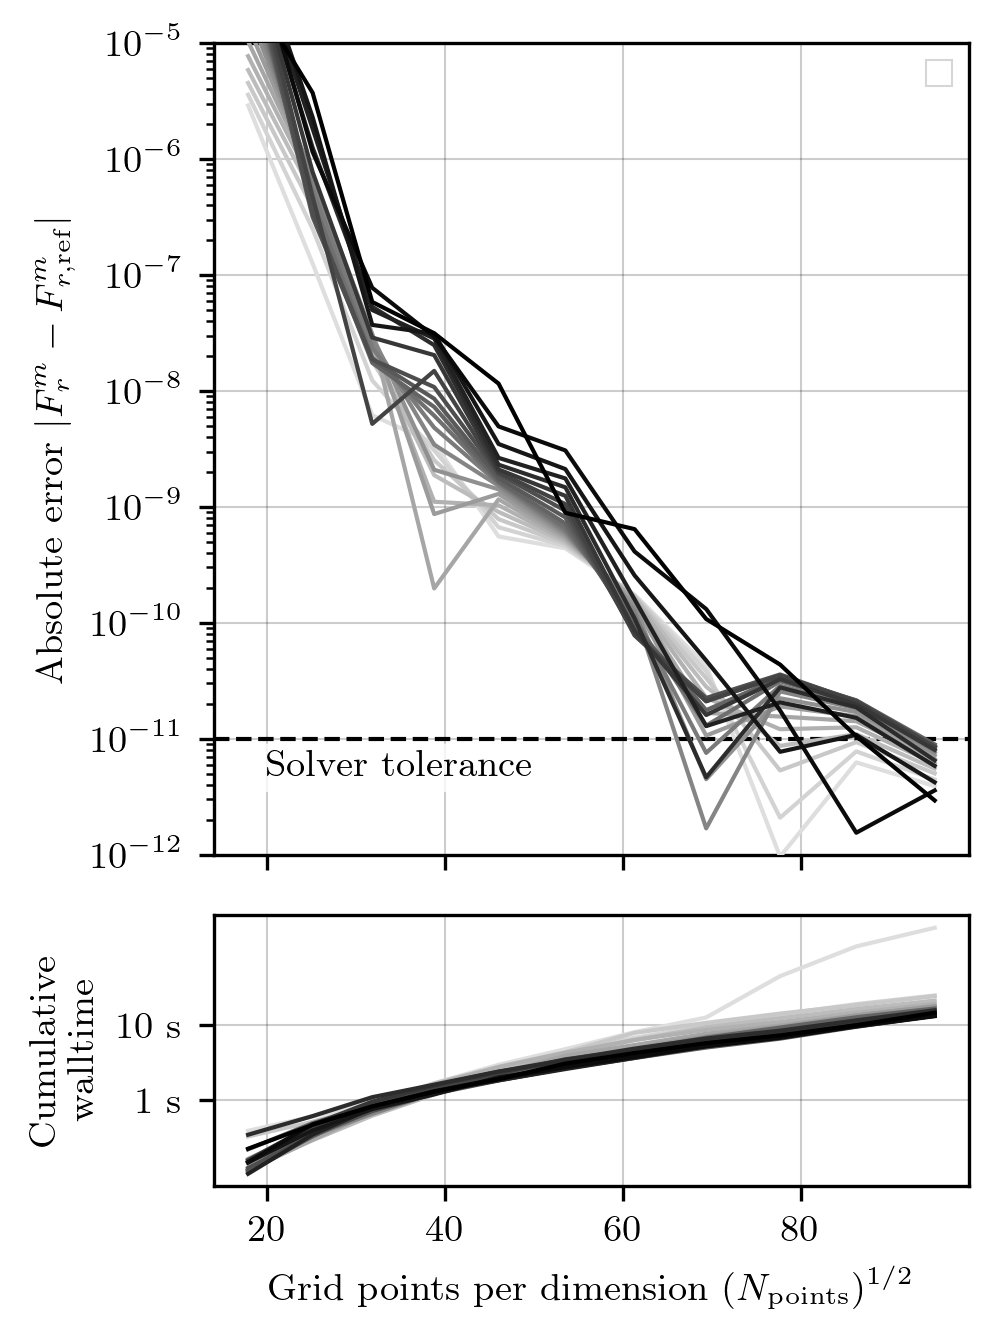

In [13]:
fig, axes = plt.subplots(figsize=(3.4, 3.4 * 4/3), nrows=2, ncols=1, sharex=True, gridspec_kw={"height_ratios": [3, 1]})
# dirs = sorted(
#     glob.glob(
#         "/Users/nilsvu/Projects/spectre/build-Default-Release/test_ssf39/m*/ScalarSelfForceReductions.h5"
#     ),
#     key=lambda x: int(x.split("/")[-2][1:]),
# )
ssf_spin = []
spins = [-0.998, -0.9, -0.7, -0.5, 0.0, 0.5, 0.7, 0.9, 0.998]
for r0 in [None]:
    r0_label = str(r0 or "isco")
    for a in [0.5]:
        r_0 = r0 or r_isco(a=a)
        dirs = sorted(
            glob.glob(
                # f"/Users/nilsvu/Projects/spectre/build-Default-Release/test_ssf64/m*/ScalarSelfForceReductions.h5"
                f"/Users/nilsvu/Projects/spectre/build-Default-Release/test_ssf71/r_{r0_label}/a{a}/m*/ScalarSelfForceReductions.h5"
                # f"/Users/nilsvu/Projects/spectre/build-Default-Release/test_ssf73/r_{r0_label}/a{a}/m*/ScalarSelfForceReductions.h5"
            ),
            key=lambda x: int(x.split("/")[-2][1:]),
        )
        if not dirs:
            continue
        ssf = pd.DataFrame(
            columns=["m", "SelfForce_r", "SelfForce_r_lo"]
        ).set_index("m")
        for i, filename in enumerate(
            dirs
            + [
                # "/Users/nilsvu/Projects/spectre/build-Default-Release/test_ssf64/m2/ScalarSelfForceReductions.h5",
                # "/Users/nilsvu/Projects/spectre/build-Default-Release/test_ssf59/ScalarSelfForceReductions.h5",
                # "/Users/nilsvu/Projects/spectre/build-Default-Release/test_ssf51/m2/ScalarSelfForceReductions.h5",
                # "/Users/nilsvu/Projects/spectre/build-Default-Release/test_ssf42/m1/ScalarSelfForceReductions.h5",
                # "/Users/nilsvu/Projects/spectre/build-Default-Release/test_ssf32/m1/ScalarSelfForceReductions.h5",
            ]
        ):
            m = int(filename.split("/")[-2][1:])
            # m = 1
            # P = int(filename.split("/")[-3][1:])
            df = get_data(filename)
            if len(df) <= 0:
                continue
            ref = df.iloc[-1]["SelfForce_r"]
            # ref = reference_sf[m, 1]
            err = np.abs(df["SelfForce_r"] - ref)
            n = -1
            df = df.iloc[:n]
            err = err.iloc[:n]
            color = 3 * [m / 23] if i < len(dirs) else f"C{i}"
            plt.sca(axes[0])
            plt.plot(
                df["NumPoints"] ** (1 / 2),
                err,
                # label=f"m={m}" if m == 0 or m == len(dirs) - 1 else None,
                color=color,
                zorder=100 - m,
                # ls={
                #     2: ":",
                #     3: "solid",
                #     4: "dashed",
                #     5: "dotted",
                #     6: "dashdot",
                # }[P]
                # alpha=1.0 if i >= len(dirs) else 0.5,
                # marker=".",
            )
            # plt.scatter(
            #     num_points.iloc[-2] ** (1 / 2),
            #     err.iloc[-1],
            #     color=color,
            #     zorder=200 - m,
            # )
            ssf.loc[m] = [ref, df["SelfForce_r"].iloc[-1]]
            plt.sca(axes[1])
            # continue
            plt.plot(
                df["NumPoints"]**(1/2), df["Walltime"],
                # marker=".",
                color=color,
                zorder=100 - m,
            )
        ssf_spin.append((r0, a, *ssf_stats(ssf, r0=r_0, a=a, isco=r0 is None)))
ssf_spin = pd.DataFrame(
    ssf_spin, columns=["r0", "a", "SelfForce_r", "Error_m", "Error_res", "Error_ref"]
).set_index(["r0", "a"])
plt.sca(axes[0])
plt.axhline(1e-11, color="k", linestyle="--", zorder=10)
plt.annotate(
    "Solver tolerance",
    (20, 1e-11),
    rotation=0,
    va="top",
    ha="left",
    xytext=(0, -3),
    textcoords="offset points",
    bbox=dict(
        boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.8
    ),
)
plt.legend(
    # title=f"$a={a}, r_0={r0 or 'ISCO'}$", alignment="left", title_fontsize="small"
)
plt.yscale("log")
plt.grid()
plt.ylim(1e-12, 1e-5)
# plt.xlim(num_points.iloc[1]**0.5, num_points.iloc[-2]**0.5)
plt.ylabel("Absolute error $|F_r^m - F_{r,\mathrm{ref}}^m|$")
plt.sca(axes[1])
plt.grid()
plt.yscale("log")
plt.ylabel("Cumulative\nwalltime")
plt.xlabel("Grid points per dimension $(N_\mathrm{points})^{1/2}$")
plt.yticks([1, 10], labels=["1 s", "10 s"])
# plt.savefig("ssf_convergence.pdf")

In [14]:
ssf_spin

,,SelfForce_r,Error_m,Error_res,Error_ref
r0,a,,,,
NaN,5.000000e-01,-6.928906e-05,2.932707e-04,1.886228e-06,9.754862e-04


<>:14: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:14: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/var/folders/xp/5t2ny359187c4ljckf8sz3m80000gn/T/ipykernel_95422/913791929.py:14: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  f"$r_0 = {r0 or '\mathrm{ISCO}'}$",


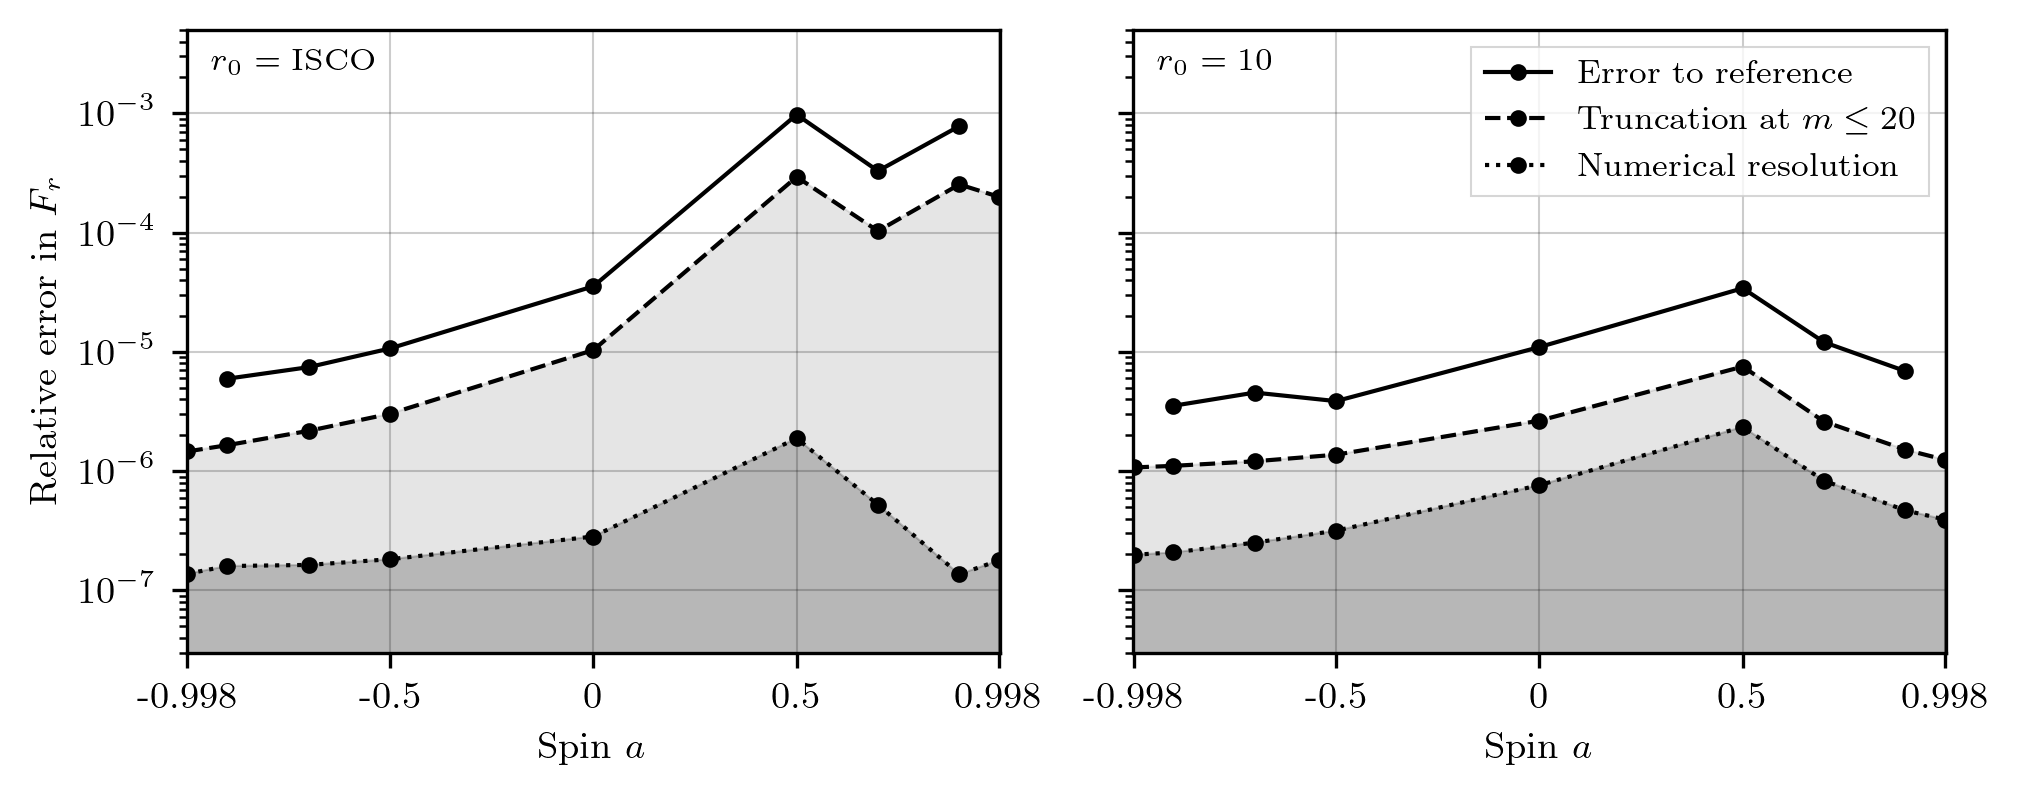

In [12]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(3.4 * 2, 3.4 * 0.8), sharey=True)
for i, r0 in enumerate([None, 10]):
    df = ssf_spin.loc[r0]
    plt.sca(axes[i])
    # Error to reference
    plt.semilogy(df.index, df["Error_ref"], marker=".", label="Error to reference", color="black", ls="-", zorder=5)
    # Error to next m-mode
    plt.semilogy(df.index, df["Error_m"], marker=".", label=r"Truncation at $m \leq 20$", color="black", ls="dashed", zorder=10)
    plt.fill_between(df.index, df["Error_m"], zorder=10, alpha=0.1, color="black")
    # Resolution error
    plt.semilogy(df.index, df["Error_res"], marker=".", label="Numerical resolution", color="black", zorder=20, ls="dotted")
    plt.fill_between(df.index, df["Error_res"], zorder=20, alpha=0.2, color="black")
    plt.annotate(
        f"$r_0 = {r0 or '\mathrm{ISCO}'}$",
        (0.03, 0.97),
        xycoords="axes fraction",
        ha="left",
        va="top",
        fontsize="small",
    )
    plt.xlabel("Spin $a$")
    plt.xlim(-1, 1)
    plt.xticks([-0.998, -0.5, 0.0, 0.5, 0.998], labels=["-0.998", "-0.5", "0", "0.5", "0.998"])
    plt.ylim(3e-8, 5e-3)
    plt.grid()
axes[0].set_ylabel("Relative error in $F_r$")
plt.legend()
# plt.savefig("ssf_error_budget.pdf")

In [20]:
ssf[["SelfForce_r"]].to_csv("ssf_isco_a0.5.csv")

Text(0, 0.5, 'Contribution to $F_r$')

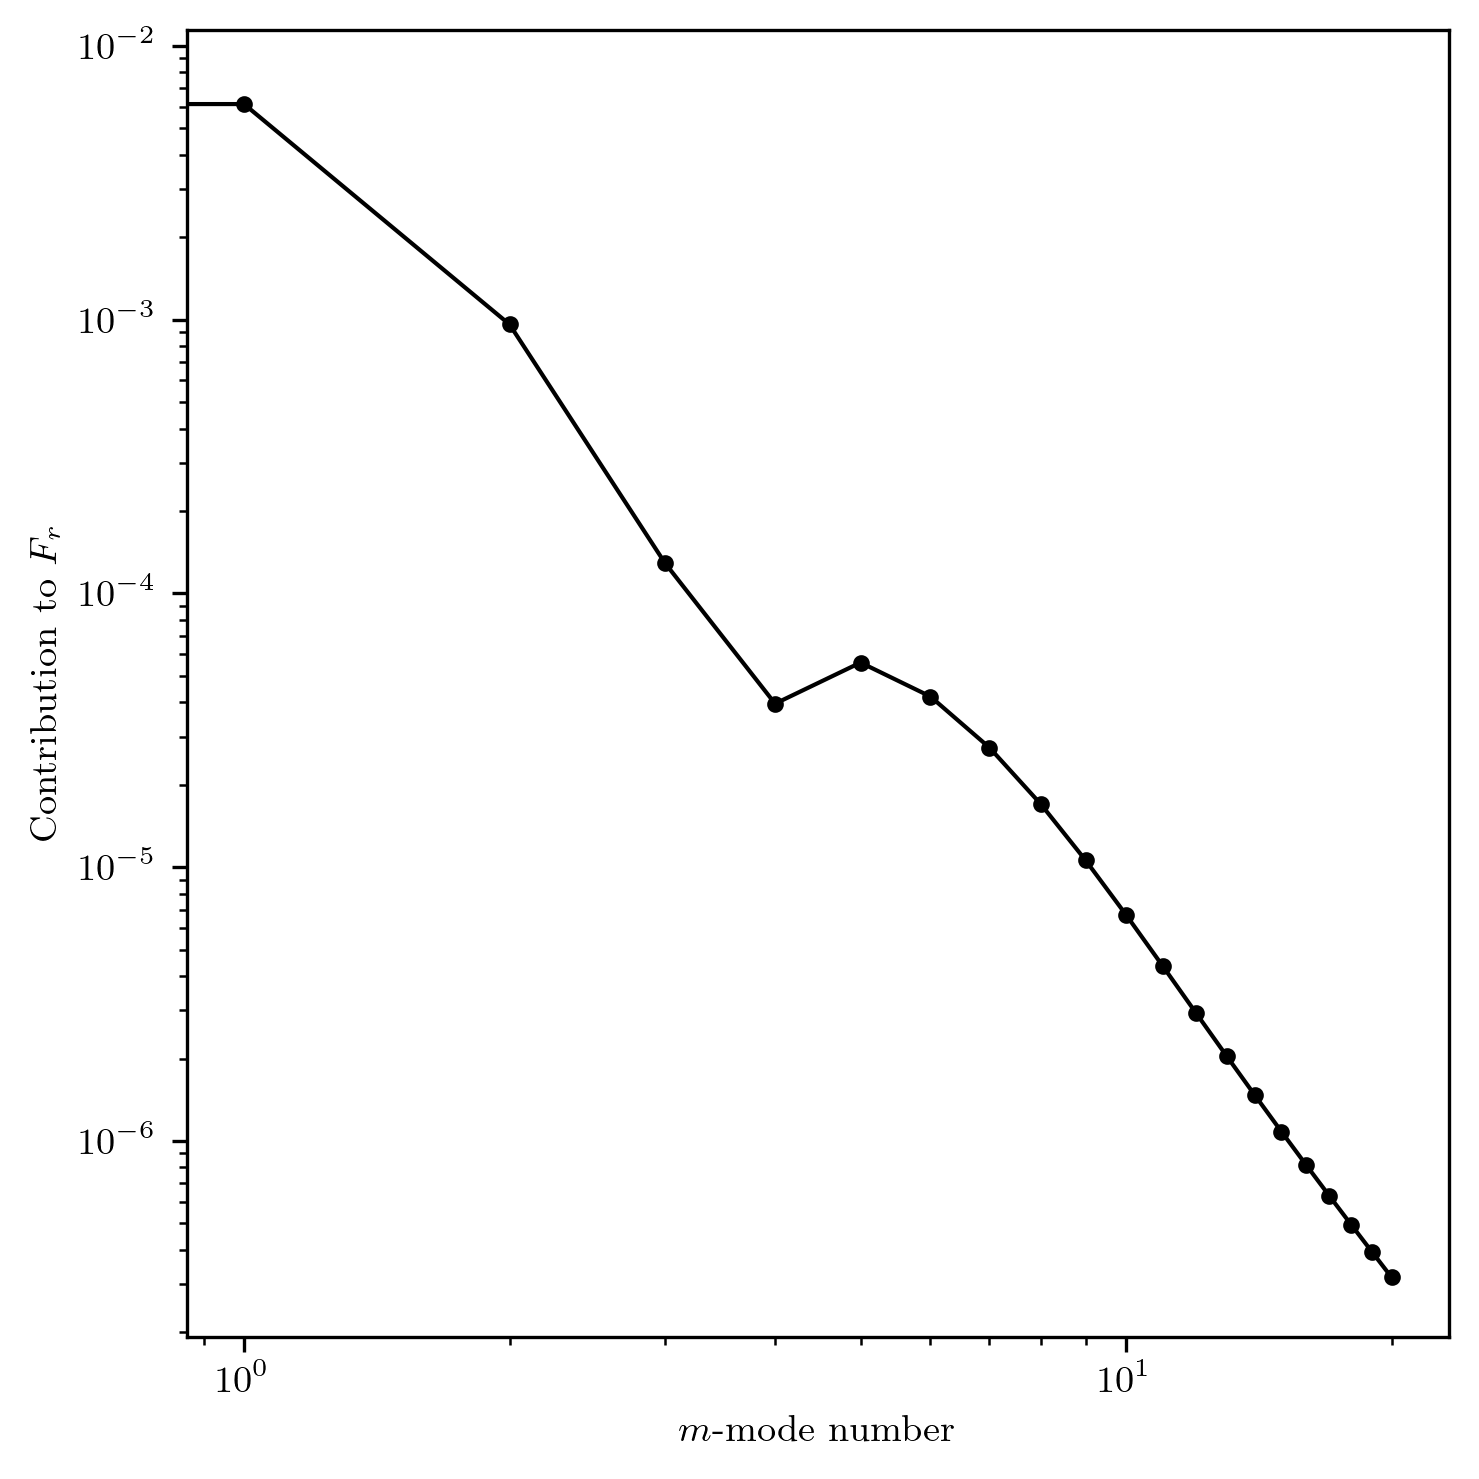

In [18]:
plt.figure(figsize=(5, 5))
plt.loglog(ssf.index, np.abs(ssf["SelfForce_r"]), marker=".", color="black")
plt.xlabel("$m$-mode number")
plt.ylabel("Contribution to $F_r$")

In [510]:
ssf_stats(ssf, r0=r_0, a=a)
# -4.03517e-6

(np.float64(-4.035307887992799e-06),
 np.float64(7.526845421629205e-06),
 np.float64(2.3460307588472744e-06))

---

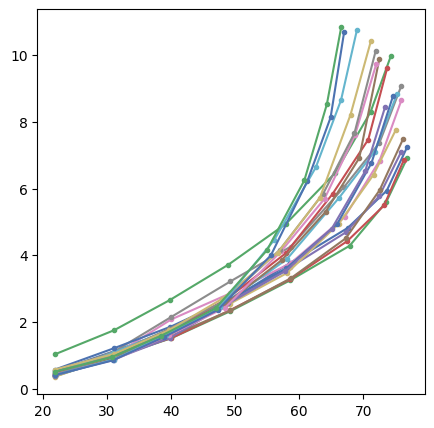

In [ ]:
plt.figure(figsize=(5, 5))
for dir in dirs:
    with h5py.File(
        dir,
        "r",
    ) as h5file:
        amr_iterations = split_iteration_sequence(to_dataframe(h5file["GmresResiduals.dat"]).set_index("Iteration"))
        num_points = to_dataframe(h5file["Norms.dat"])["NumberOfPoints"].iloc[1:]
    plt.plot(num_points**0.5, [df["Walltime"].iloc[-1] for df in amr_iterations], marker=".")

---

In [170]:
with h5py.File(
    "/Users/nilsvu/Projects/spectre/build-Default-Release/test_ssf2_m1/ScalarSelfForceReductions.h5",
    "r",
) as h5file:
    df = to_dataframe(h5file["SelfForce.dat"])
    num_points = to_dataframe(h5file["Norms.dat"])["NumberOfPoints"]

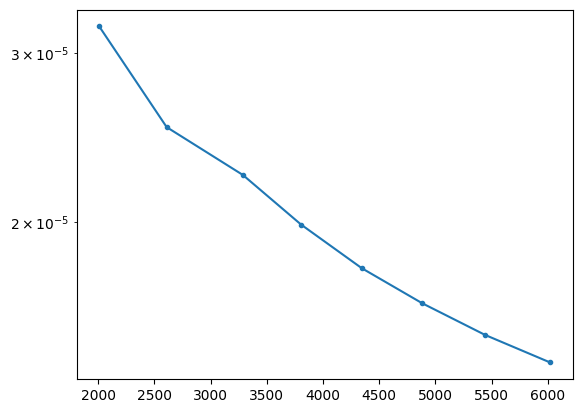

In [113]:
df_std = df.groupby("IterationId").std()
plt.plot(
    num_points[1:-1],
    df_std["Re(SelfForce_r)"].iloc[1:-1],
    marker="."
)
plt.yscale("log")

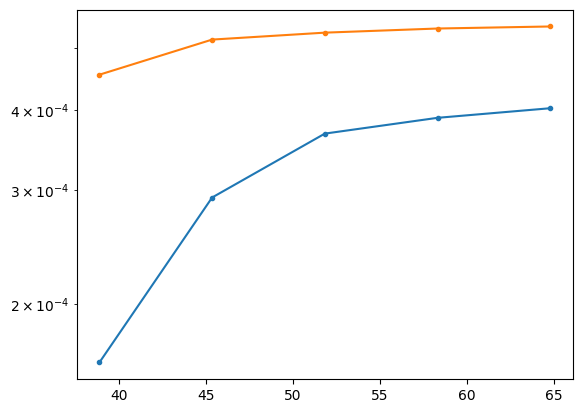

In [124]:
ref = (
    get_data(
        "/Users/nilsvu/Projects/spectre/build-Default-Release/test_ssf18_m1/ScalarSelfForceReductions.h5"
    )[0]
    .groupby("IterationId")
    .mean()
    .iloc[-1]
)
for i, filename in enumerate(
    [
        # "/Users/nilsvu/Projects/spectre/build-Default-Release/test_ssf_m1/ScalarSelfForceReductions.h5",
        # "/Users/nilsvu/Projects/spectre/build-Default-Release/test_ssf2_m1/ScalarSelfForceReductions.h5",
        # "/Users/nilsvu/Projects/spectre/build-Default-Release/test_ssf3_m1/ScalarSelfForceReductions.h5",
        # "/Users/nilsvu/Projects/spectre/build-Default-Release/test_ssf4_m1/ScalarSelfForceReductions.h5",
        # "/Users/nilsvu/Projects/spectre/build-Default-Release/test_ssf5_m1/ScalarSelfForceReductions.h5",
        # "/Users/nilsvu/Projects/spectre/build-Default-Release/test_ssf6_m1/ScalarSelfForceReductions.h5",
        "/Users/nilsvu/Projects/spectre/build-Default-Release/test_ssf17_m1/ScalarSelfForceReductions.h5",
        "/Users/nilsvu/Projects/spectre/build-Default-Release/test_ssf19_m1/ScalarSelfForceReductions.h5",
    ]
):
    df, num_points = get_data(filename)
    df_mean = df.groupby("IterationId").mean()
    plt.plot(
        num_points[1:] ** (1 / 2),
        np.abs(
            df_mean["Re(SelfForce_r)"].iloc[1:]
            # - df_mean["Re(SelfForce_r)"].iloc[-1]
            - ref["Re(SelfForce_r)"]
        ),
        marker=".",
    )
plt.yscale("log")


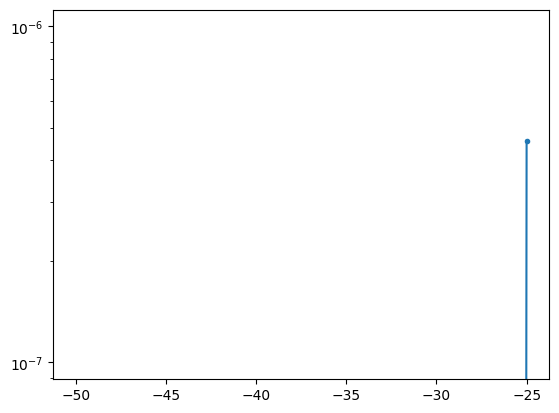

In [122]:
dir = "/Users/nilsvu/Projects/spectre/build-Default-Release"
data = []
# for R in [100, 200, 300, 400]:
for R in [-25, -50]:
    df, num_points = get_data(
        f"{dir}/test_ssf14_m1/Rin{R}/ScalarSelfForceReductions.h5"
    )
    df_mean = df.groupby("IterationId").mean()
    data.append((R, df_mean.iloc[-1]["Re(SelfForce_r)"]))
data = np.array(data)
plt.plot(
    data[:, 0],
    np.abs(data[:, 1] - data[-1, 1]),
    marker=".",
)
plt.yscale("log")


   SelfForce_r
m             
0     0.006934
1    -0.006138
2    -0.000961
3    -0.000129
4     0.000039
5     0.000056
6     0.000042
7     0.000027
8     0.000017
9     0.000011
10    0.000007
Before regularization: -9.49576829051947e-05
-8.123019918137199e-05


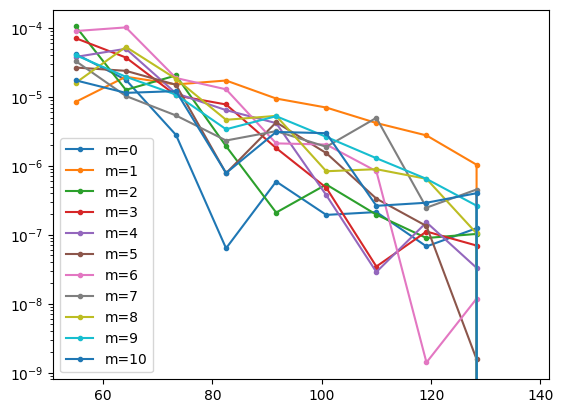

In [57]:
dirs = sorted(
    glob.glob(
        "/Users/nilsvu/Projects/spectre/build-Default-Release/test_ssf26/m*/ScalarSelfForceReductions.h5"
    ),
    key=lambda x: int(x.split("/")[-2][1:]),
)
for filename in dirs:
    m = int(filename.split("/")[-2][1:])
    df, num_points = get_data(filename)
    df_mean = df.groupby("IterationId").mean()
    plt.plot(
        num_points[1:] ** (1 / 2),
        np.abs(
            df_mean["Re(SelfForce_r)"].iloc[1:]
            # - df_mean["Re(SelfForce_r)"].iloc[-1]
            - df_mean["Re(SelfForce_r)"].iloc[-1]
        ),
        marker=".",
        label=f"m={m}",
    )
plt.legend()
plt.yscale("log")
assemble_scalar_self_force(dirs, r0=4.2330025279799335, a=0.5)
# for a=0.5, r0=isco:
# F_r = −6.922147e−5


   SelfForce_r
m             
0     0.006934
1    -0.006138
2    -0.000961
3    -0.000129
4     0.000039
5     0.000055
6     0.000041
7     0.000025
8     0.000012
9      0.00001
10    0.000018
Before regularization: -9.461212245058013e-05
-8.088463872675742e-05


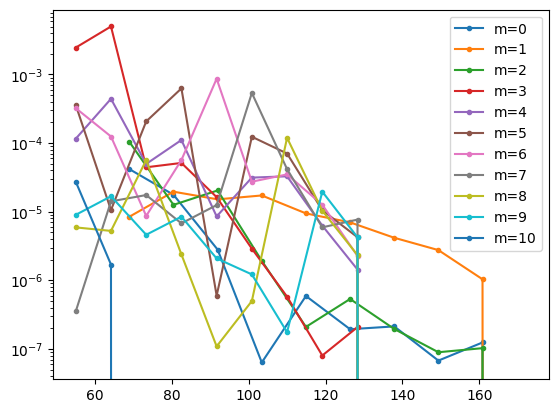

In [59]:
dirs = sorted(
    glob.glob(
        "/Users/nilsvu/Projects/spectre/build-Default-Release/test_ssf27/m*/ScalarSelfForceReductions.h5"
    ),
    key=lambda x: int(x.split("/")[-2][1:]),
)
for filename in dirs:
    m = int(filename.split("/")[-2][1:])
    df, num_points = get_data(filename)
    df_mean = df.groupby("IterationId").mean()
    plt.plot(
        num_points[1:] ** (1 / 2),
        np.abs(
            df_mean["Re(SelfForce_r)"].iloc[1:]
            # - df_mean["Re(SelfForce_r)"].iloc[-1]
            - df_mean["Re(SelfForce_r)"].iloc[-1]
        ),
        marker=".",
        label=f"m={m}",
    )
plt.legend()
plt.yscale("log")
assemble_scalar_self_force(dirs, r0=4.2330025279799335, a=0.5)
# for a=0.5, r0=isco:
# F_r = −6.922147e−5


In [ ]:
# a=0.9, r0=isco, m=1
expected_dpsi_drstar = -0.0242004 - 0.00723707j
expected_F_r = -0.0700412
# a=0.5, r0=6, m=1
dpsi_dr = -0.00320376 + 0.00162401j
F_r = -0.00120398
# m=0
dpsi_dr = 0.00355094
F_r = 0.00123093

In [25]:
df = get_data(*glob.glob("/Users/nilsvu/Projects/spectre/build-Default-Release/test_ssf24_*/m1/ScalarSelfForceReductions.h5"))[0]
df_mean = df.groupby("IterationId")["Re(SelfForce_r)"].mean()
df_mean


IterationId
0.0    0.000000
1.0   -0.001148
2.0   -0.001179
3.0   -0.001191
4.0   -0.001196
5.0   -0.001199
6.0   -0.001201
7.0   -0.001202
8.0   -0.001203
Name: Re(SelfForce_r), dtype: float64